# This is a visualisation of the second Prometheus Capital Weekly Quant Radar (WQR_2).
* Compares the simple equal-weighted 1/n portfolio with robust Markowitz mean-variance optimisation.
  * Covariance and mean shrinkage.
  * Bayesian priors.
  * Weight constraints.
* Shows how estimation error in expected returns and covariances can make optimised portfolios unstable.
* Highlights why 1/n can remain a strong out-of-sample benchmark despite its simplicity.

Import relevant libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Load dataset

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Prometheus/WQR/dataset_for_portfolio_construction.csv")

Data cleaning

In [6]:
# ==============================================================================
# DATA CLEANING
# ==============================================================================
# Set date
df["date"] = pd.to_datetime(df["date"])

# Handle nan in data
df = df[df[["PERMNO", "date", "TICKER", "PRC", "sprtrn"]].notna()]

# Creating returns
df = df.sort_values(by=["PERMNO", "TICKER", "date"])
df["returns"] = df["PRC"].pct_change()

# Drop duplicates
df = df.drop_duplicates(subset=["date", "PERMNO", "TICKER"])

# Create columns for each TICKER with accompanying returns
df = df.pivot(
    index=["date", "sprtrn"],
    columns="TICKER",
    values="returns")

df.columns.name = None
df = df.reset_index()

# Keep only dates after 2000
df = df[df["date"] >= "2000-01-01"]

# Rename "sprtrn" to "market"
df = df.rename(columns={"sprtrn" : "Market"})

Shared functions

In [7]:
# ==============================================================================
# SHARED FUNCTIONS
# ==============================================================================
# Markowitz optimiser
def optimize_markowitz(mu, sigma, bounds=(0, 1)):
    n = len(mu)

    def negative_sharpe(weights):
        portfolio_return = weights @ mu
        portfolio_vol = np.sqrt(weights @ sigma @ weights)

        if portfolio_vol == 0:
            return 1e10

        return -portfolio_return / portfolio_vol

    constraints = ({
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1})

    bounds = [bounds] * n
    initial_weights = np.ones(n) / n

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints)

    if not result.success:
        return initial_weights

    return result.x

# Mean shrinkage
def shrink_mean(mu, shrinkage=0.50):
    grand_mean = np.mean(mu)

    return (1 - shrinkage) * mu + shrinkage * grand_mean

# Covariance shrinkage
def shrink_covariance(R_train):
    lw = LedoitWolf()
    lw.fit(R_train)

    return lw.covariance_

# Sharpe ratio
def annual_sharpe(return_series, periods_per_year=252):
    annual_return = return_series.mean() * periods_per_year
    annual_volatility = return_series.std() * np.sqrt(periods_per_year)

    if annual_volatility == 0:
        return np.nan

    return annual_return / annual_volatility

Performance of 1/n and robust Markowitz portfolios
* Fixed split 70/30.

                      In-sample Sharpe  Out-of-sample Sharpe
1/n                           0.485732              0.662268
Classical Markowitz           0.614716              0.169923
Mean Shrinkage                0.522605              0.480750
Covariance Shrinkage          0.614446              0.198748
Bayesian Prior                0.522605              0.480750
Weight Constraint             0.589539              0.418240
Robust Combined               0.526861              0.502197
Market                        0.244457              0.715480


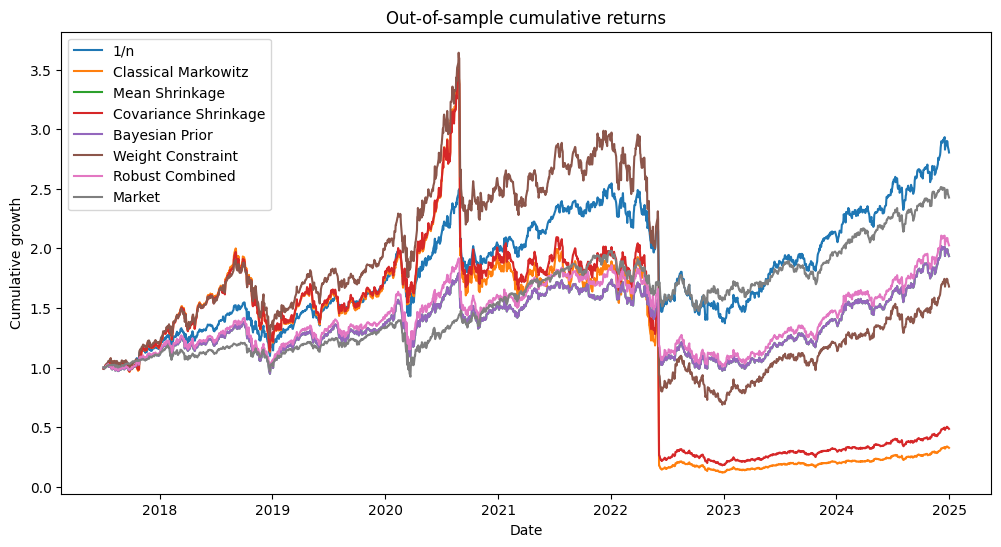

In [9]:
# ==============================================================================
# 1. SETUP
# ==============================================================================
universe = ["AAPL", "AMZN", "IBM", "MSFT", "Market"]

stock_cols = universe[:-1]
market_col = universe[-1]

returns = df[["date"] + stock_cols + [market_col]].dropna().reset_index(drop=True)

R = returns[stock_cols]
dates = returns["date"]

# ==============================================================================
# 2. MAIN ENGINE
# ==============================================================================
split_index = int(len(returns) * 0.70)

in_sample = returns.iloc[:split_index].copy()
out_sample = returns.iloc[split_index:].copy()

R_in = in_sample[stock_cols]
R_out = out_sample[stock_cols]

# Estimating Markowitz, using in-sample data
mu_in = R_in.mean().values
sigma_in = R_in.cov().values

# Shrinkage
mu_shrunk = shrink_mean(mu_in, shrinkage=0.50)
sigma_shrunk = shrink_covariance(R_in)

# Bayesian-style prior
mu_prior = np.ones(len(stock_cols)) * np.mean(mu_in)
mu_bayesian = 0.50 * mu_in + 0.50 * mu_prior

# Weight constraints
w_markowitz = optimize_markowitz(mu_in, sigma_in, bounds=(-1, 1))

w_mean_shrinkage = optimize_markowitz(mu_shrunk, sigma_in, bounds=(-1, 1))

w_cov_shrinkage = optimize_markowitz(mu_in, sigma_shrunk, bounds=(-1, 1))

w_bayesian = optimize_markowitz(mu_bayesian, sigma_in, bounds=(-1, 1))

w_constrained = optimize_markowitz(mu_in, sigma_in, bounds=(0, 1))

w_robust_combined = optimize_markowitz(mu_shrunk, sigma_shrunk, bounds=(0, 1))

w_equal = np.ones(len(stock_cols)) / len(stock_cols)

# ==============================================================================
# 3. VISUALISATION ENGINE
# ==============================================================================
# In-sample metrics
in_sample_results = pd.DataFrame({
    "date": in_sample["date"],
    "equal_weight": R_in.values @ w_equal,
    "markowitz": R_in.values @ w_markowitz,
    "mean_shrinkage": R_in.values @ w_mean_shrinkage,
    "cov_shrinkage": R_in.values @ w_cov_shrinkage,
    "bayesian": R_in.values @ w_bayesian,
    "constrained": R_in.values @ w_constrained,
    "robust_combined": R_in.values @ w_robust_combined,
    "market": in_sample[market_col].values})

# Out-of-sample metrics
out_sample_results = pd.DataFrame({
    "date": out_sample["date"],
    "equal_weight": R_out.values @ w_equal,
    "markowitz": R_out.values @ w_markowitz,
    "mean_shrinkage": R_out.values @ w_mean_shrinkage,
    "cov_shrinkage": R_out.values @ w_cov_shrinkage,
    "bayesian": R_out.values @ w_bayesian,
    "constrained": R_out.values @ w_constrained,
    "robust_combined": R_out.values @ w_robust_combined,
    "market": out_sample[market_col].values})

# Performance across subsets
performance = pd.DataFrame({
    "In-sample Sharpe": {
        "1/n": annual_sharpe(in_sample_results["equal_weight"]),
        "Classical Markowitz": annual_sharpe(in_sample_results["markowitz"]),
        "Mean Shrinkage": annual_sharpe(in_sample_results["mean_shrinkage"]),
        "Covariance Shrinkage": annual_sharpe(in_sample_results["cov_shrinkage"]),
        "Bayesian Prior": annual_sharpe(in_sample_results["bayesian"]),
        "Weight Constraint": annual_sharpe(in_sample_results["constrained"]),
        "Robust Combined": annual_sharpe(in_sample_results["robust_combined"]),
        "Market": annual_sharpe(in_sample_results["market"])},
    "Out-of-sample Sharpe": {
        "1/n": annual_sharpe(out_sample_results["equal_weight"]),
        "Classical Markowitz": annual_sharpe(out_sample_results["markowitz"]),
        "Mean Shrinkage": annual_sharpe(out_sample_results["mean_shrinkage"]),
        "Covariance Shrinkage": annual_sharpe(out_sample_results["cov_shrinkage"]),
        "Bayesian Prior": annual_sharpe(out_sample_results["bayesian"]),
        "Weight Constraint": annual_sharpe(out_sample_results["constrained"]),
        "Robust Combined": annual_sharpe(out_sample_results["robust_combined"]),
        "Market": annual_sharpe(out_sample_results["market"])}})

print(performance)

# Graphs
out_sample_plot = out_sample_results.copy()

out_sample_plot["1/n"] = (1 + out_sample_plot["equal_weight"]).cumprod()
out_sample_plot["Classical Markowitz"] = (1 + out_sample_plot["markowitz"]).cumprod()
out_sample_plot["Mean Shrinkage"] = (1 + out_sample_plot["mean_shrinkage"]).cumprod()
out_sample_plot["Covariance Shrinkage"] = (1 + out_sample_plot["cov_shrinkage"]).cumprod()
out_sample_plot["Bayesian Prior"] = (1 + out_sample_plot["bayesian"]).cumprod()
out_sample_plot["Weight Constraint"] = (1 + out_sample_plot["constrained"]).cumprod()
out_sample_plot["Robust Combined"] = (1 + out_sample_plot["robust_combined"]).cumprod()
out_sample_plot["Market"] = (1 + out_sample_plot["market"]).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(out_sample_plot["date"], out_sample_plot["1/n"], label="1/n")
plt.plot(out_sample_plot["date"], out_sample_plot["Classical Markowitz"], label="Classical Markowitz")
plt.plot(out_sample_plot["date"], out_sample_plot["Mean Shrinkage"], label="Mean Shrinkage")
plt.plot(out_sample_plot["date"], out_sample_plot["Covariance Shrinkage"], label="Covariance Shrinkage")
plt.plot(out_sample_plot["date"], out_sample_plot["Bayesian Prior"], label="Bayesian Prior")
plt.plot(out_sample_plot["date"], out_sample_plot["Weight Constraint"], label="Weight Constraint")
plt.plot(out_sample_plot["date"], out_sample_plot["Robust Combined"], label="Robust Combined")
plt.plot(out_sample_plot["date"], out_sample_plot["Market"], label="Market")

plt.title("Out-of-sample cumulative returns")
plt.xlabel("Date")
plt.ylabel("Cumulative growth")
plt.legend()
plt.show()

Performance of 1/n and robust Markowitz portfolios
* 70/30 split.
* Expanding-window backtest.

                      In-sample Sharpe  Out-of-sample Sharpe
1/n                           0.521412              0.662268
Classical Markowitz           0.598640              0.249018
Mean Shrinkage                0.519300              0.505406
Covariance Shrinkage          0.598956              0.266190
Bayesian Prior                0.519300              0.505406
Weight Constraint             0.591709              0.356212
Robust Combined               0.524950              0.520010
Market                        0.313238              0.715480


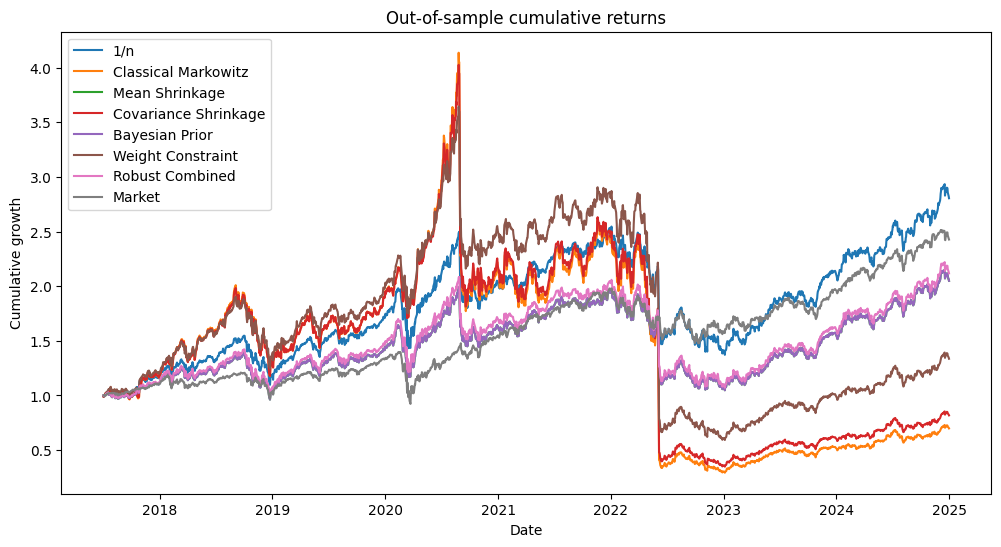

In [10]:
# ==============================================================================
# 1. SETUP
# ==============================================================================
universe = ["AAPL", "AMZN", "IBM", "MSFT", "Market"]

stock_cols = universe[:-1]
market_col = universe[-1]

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

returns = df[["date"] + stock_cols + [market_col]].dropna().reset_index(drop=True)

R = returns[stock_cols]

w_equal = np.ones(len(stock_cols)) / len(stock_cols)

# ==============================================================================
# 2. MAIN ENGINE
# ==============================================================================
initial_train_size = int(len(returns) * 0.70)
rebalance_frequency = 252

all_is_results = []
all_oos_results = []

start = initial_train_size

while start < len(returns):

    end = min(start + rebalance_frequency, len(returns))

    # Expanding in-sample window
    train_data = returns.iloc[:start].copy()
    R_train = train_data[stock_cols]

    # 1-year out-of-sample window
    test_data = returns.iloc[start:end].copy()
    R_test = test_data[stock_cols]

    # Estimating inputs, using in-sample data
    mu_train = R_train.mean().values
    sigma_train = R_train.cov().values

    # Shrinkage
    mu_shrunk = shrink_mean(mu_train, shrinkage=0.50)
    sigma_shrunk = shrink_covariance(R_train)

    # Bayesian-style prior
    mu_prior = np.ones(len(stock_cols)) * np.mean(mu_train)
    mu_bayesian = 0.50 * mu_train + 0.50 * mu_prior

    # Portfolio weights
    w_markowitz = optimize_markowitz(mu_train, sigma_train, bounds=(-1, 1))

    w_mean_shrinkage = optimize_markowitz(mu_shrunk, sigma_train, bounds=(-1, 1))

    w_cov_shrinkage = optimize_markowitz(mu_train, sigma_shrunk, bounds=(-1, 1))

    w_bayesian = optimize_markowitz(mu_bayesian, sigma_train, bounds=(-1, 1))

    w_constrained = optimize_markowitz(mu_train, sigma_train, bounds=(0, 1))

    w_robust_combined = optimize_markowitz(mu_shrunk, sigma_shrunk, bounds=(0, 1))

    # In-sample metrics
    train_results = pd.DataFrame({
        "date": train_data["date"].values,
        "equal_weight": R_train.values @ w_equal,
        "markowitz": R_train.values @ w_markowitz,
        "mean_shrinkage": R_train.values @ w_mean_shrinkage,
        "cov_shrinkage": R_train.values @ w_cov_shrinkage,
        "bayesian": R_train.values @ w_bayesian,
        "constrained": R_train.values @ w_constrained,
        "robust_combined": R_train.values @ w_robust_combined,
        "market": train_data[market_col].values})

    # Out-of-sample metrics
    test_results = pd.DataFrame({
        "date": test_data["date"].values,
        "equal_weight": R_test.values @ w_equal,
        "markowitz": R_test.values @ w_markowitz,
        "mean_shrinkage": R_test.values @ w_mean_shrinkage,
        "cov_shrinkage": R_test.values @ w_cov_shrinkage,
        "bayesian": R_test.values @ w_bayesian,
        "constrained": R_test.values @ w_constrained,
        "robust_combined": R_test.values @ w_robust_combined,
        "market": test_data[market_col].values})

    all_is_results.append(train_results)

    all_oos_results.append(test_results)

    start = end

# ==============================================================================
# 3. VISUALISATION ENGINE
# ==============================================================================
in_sample_results = pd.concat(all_is_results, ignore_index=True)
out_sample_results = pd.concat(all_oos_results, ignore_index=True)

# Performance across subsets
performance = pd.DataFrame({
    "In-sample Sharpe": {
        "1/n": annual_sharpe(in_sample_results["equal_weight"]),
        "Classical Markowitz": annual_sharpe(in_sample_results["markowitz"]),
        "Mean Shrinkage": annual_sharpe(in_sample_results["mean_shrinkage"]),
        "Covariance Shrinkage": annual_sharpe(in_sample_results["cov_shrinkage"]),
        "Bayesian Prior": annual_sharpe(in_sample_results["bayesian"]),
        "Weight Constraint": annual_sharpe(in_sample_results["constrained"]),
        "Robust Combined": annual_sharpe(in_sample_results["robust_combined"]),
        "Market": annual_sharpe(in_sample_results["market"])},
    "Out-of-sample Sharpe": {
        "1/n": annual_sharpe(out_sample_results["equal_weight"]),
        "Classical Markowitz": annual_sharpe(out_sample_results["markowitz"]),
        "Mean Shrinkage": annual_sharpe(out_sample_results["mean_shrinkage"]),
        "Covariance Shrinkage": annual_sharpe(out_sample_results["cov_shrinkage"]),
        "Bayesian Prior": annual_sharpe(out_sample_results["bayesian"]),
        "Weight Constraint": annual_sharpe(out_sample_results["constrained"]),
        "Robust Combined": annual_sharpe(out_sample_results["robust_combined"]),
        "Market": annual_sharpe(out_sample_results["market"])}})

print(performance)

# Graphs
out_sample_plot = out_sample_results.copy()

out_sample_plot["1/n"] = (1 + out_sample_plot["equal_weight"]).cumprod()
out_sample_plot["Classical Markowitz"] = (1 + out_sample_plot["markowitz"]).cumprod()
out_sample_plot["Mean Shrinkage"] = (1 + out_sample_plot["mean_shrinkage"]).cumprod()
out_sample_plot["Covariance Shrinkage"] = (1 + out_sample_plot["cov_shrinkage"]).cumprod()
out_sample_plot["Bayesian Prior"] = (1 + out_sample_plot["bayesian"]).cumprod()
out_sample_plot["Weight Constraint"] = (1 + out_sample_plot["constrained"]).cumprod()
out_sample_plot["Robust Combined"] = (1 + out_sample_plot["robust_combined"]).cumprod()
out_sample_plot["Market"] = (1 + out_sample_plot["market"]).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(out_sample_plot["date"], out_sample_plot["1/n"], label="1/n")
plt.plot(out_sample_plot["date"], out_sample_plot["Classical Markowitz"], label="Classical Markowitz")
plt.plot(out_sample_plot["date"], out_sample_plot["Mean Shrinkage"], label="Mean Shrinkage")
plt.plot(out_sample_plot["date"], out_sample_plot["Covariance Shrinkage"], label="Covariance Shrinkage")
plt.plot(out_sample_plot["date"], out_sample_plot["Bayesian Prior"], label="Bayesian Prior")
plt.plot(out_sample_plot["date"], out_sample_plot["Weight Constraint"], label="Weight Constraint")
plt.plot(out_sample_plot["date"], out_sample_plot["Robust Combined"], label="Robust Combined")
plt.plot(out_sample_plot["date"], out_sample_plot["Market"], label="Market")

plt.title("Out-of-sample cumulative returns")
plt.xlabel("Date")
plt.ylabel("Cumulative growth")
plt.legend()
plt.show()

# Results
* Consistent with the WQR_2 documentation, these graphs show that the simple 1/n allocation rule remains a highly competitive benchmark, even relative to robust Markowitz-based approaches.
* Although robust Markowitz portfolios achieve, on average, superior in-sample Sharpe ratios, this advantage weakens significantly out-of-sample. Even mean shrinkage, covariance shrinkage, Bayesian-style priors and explicit weight constraints do not fully prevent the optimiser from fitting historical noise rather than persistent return signals.
* This highlights the central message of the radar: robust active allocation is not about optimisation alone, but about controlling estimation error sufficiently to generate stable out-of-sample performance.
